# KNN Case Study on Diabetes

This notebook builds a Diabetes prediction model using K-Nearest Neighbors (KNN).


## 1) Import libraries


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.style.use("seaborn-v0_8")


## 2) Load and explore dataset

Using `pima-indians-diabetes.csv` (no header in the file, so we add column names).

Target: `Outcome` (0 = Non-diabetic, 1 = Diabetic).


In [13]:
cols = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]
df = pd.read_csv("pima-indians-diabetes.csv", header=None, names=cols)

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

df.head()


Shape: (768, 9)

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3) Basic EDA

Quickly check the class balance and summary stats.


Outcome
0    500
1    268
Name: count, dtype: int64

Class distribution (%):
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

Summary statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean  

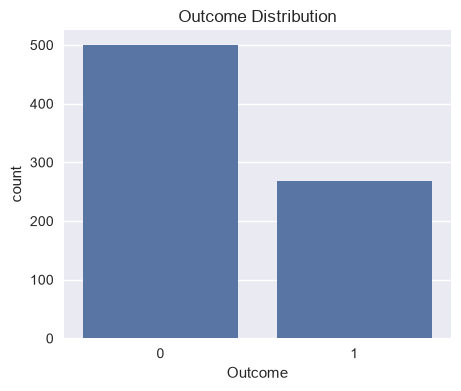

In [14]:
print(df["Outcome"].value_counts())
print("\nClass distribution (%):")
print(df["Outcome"].value_counts(normalize=True) * 100)

print("\nSummary statistics:")
print(df.describe())

plt.figure(figsize=(5, 4))
sns.countplot(x="Outcome", data=df)
plt.title("Outcome Distribution")
plt.show()


## 4) Data preprocessing

In this dataset, zero values are invalid for some medical features
(`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`).
We replace 0 with median values.


In [15]:
invalid_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in invalid_zero_cols:
    if col in df.columns:
        median_val = df[col].replace(0, np.nan).median()
        df[col] = df[col].replace(0, median_val)

print("Zero counts after imputation:")
for col in invalid_zero_cols:
    if col in df.columns:
        print(f"{col}: {(df[col] == 0).sum()}")


Zero counts after imputation:
Glucose: 0
BloodPressure: 0
SkinThickness: 0
Insulin: 0
BMI: 0


## 5) Split features and target


In [16]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (614, 8)
Test shape: (154, 8)


## 6–7) GridSearchCV: scaler + KNN params

Instead of picking one scaler / k by hand, use a Pipeline and search over:
- scalers: Standard / MinMax / Robust
- `n_neighbors`, `weights`, `metric`
- 5-fold stratified CV on the training set
- final score on the held-out test set


In [17]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# two grids so we don't waste fits on p when metric isn't minkowski
scalers = [StandardScaler(), MinMaxScaler(), RobustScaler()]
ks = list(range(3, 21, 2))  # odd k: 3,5,...,19

param_grid = [
    {
        "scaler": scalers,
        "knn__n_neighbors": ks,
        "knn__weights": ["uniform", "distance"],
        "knn__metric": ["euclidean", "manhattan"],
    },
    {
        "scaler": scalers,
        "knn__n_neighbors": ks,
        "knn__weights": ["uniform", "distance"],
        "knn__metric": ["minkowski"],
        "knn__p": [1, 2],
    },
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

grid.fit(X_train, y_train)

print("Best CV accuracy:", round(grid.best_score_, 4))
print("Best params:")
for k, v in grid.best_params_.items():
    print(f"  {k}: {v}")

results = pd.DataFrame(grid.cv_results_)
top = results.sort_values("mean_test_score", ascending=False)[
    ["mean_test_score", "std_test_score", "param_scaler", "param_knn__n_neighbors",
     "param_knn__weights", "param_knn__metric"]
].head(5)
print("\nTop 5 settings:")
print(top.to_string(index=False))


Best CV accuracy: 0.7769
Best params:
  knn__metric: euclidean
  knn__n_neighbors: 13
  knn__weights: uniform
  scaler: StandardScaler()

Top 5 settings:
 mean_test_score  std_test_score     param_scaler  param_knn__n_neighbors param_knn__weights param_knn__metric
        0.776863        0.040734 StandardScaler()                      13            uniform         euclidean
        0.776863        0.040734 StandardScaler()                      13            uniform         minkowski
        0.775237        0.034383 StandardScaler()                      13           distance         euclidean
        0.775237        0.034383 StandardScaler()                      13           distance         minkowski
        0.770332        0.030362   MinMaxScaler()                      19            uniform         euclidean


## 7b) Quick look: accuracy vs k for the best scaler/weights/metric

Just to visualize how k affects CV accuracy for the winning combo.


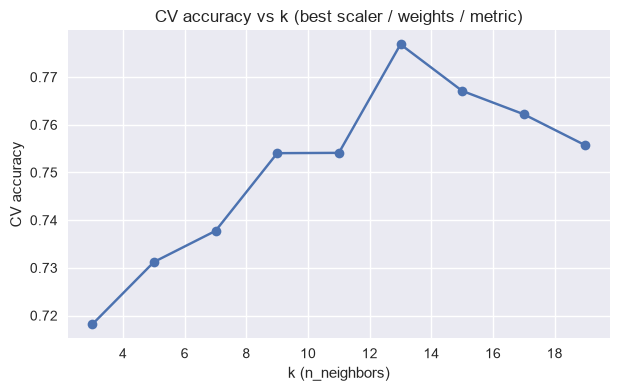

Best model from GridSearchCV:
Pipeline(steps=[('scaler', StandardScaler()),
                ('knn',
                 KNeighborsClassifier(metric='euclidean', n_neighbors=13))])


In [18]:
best = grid.best_params_
mask = (
    (results["param_knn__weights"] == best["knn__weights"]) &
    (results["param_knn__metric"] == best["knn__metric"]) &
    (results["param_scaler"].astype(str) == str(best["scaler"]))
)
if "knn__p" in best:
    mask = mask & (results["param_knn__p"] == best["knn__p"])

subset = results.loc[mask].sort_values("param_knn__n_neighbors")

plt.figure(figsize=(7, 4))
plt.plot(subset["param_knn__n_neighbors"], subset["mean_test_score"], marker="o")
plt.xlabel("k (n_neighbors)")
plt.ylabel("CV accuracy")
plt.title("CV accuracy vs k (best scaler / weights / metric)")
plt.show()

print("Best model from GridSearchCV:")
print(grid.best_estimator_)


## 8) Final model evaluation (held-out test set)

`GridSearchCV` already refits the best pipeline on all training data. We only use the test set once here.


Test accuracy: 0.7143
Best params: {'knn__metric': 'euclidean', 'knn__n_neighbors': 13, 'knn__weights': 'uniform', 'scaler': StandardScaler()}

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



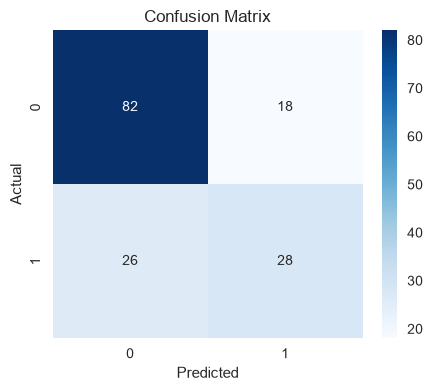

In [20]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Test accuracy:", round(acc, 4))
print("Best params:", grid.best_params_)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## 9) Short analysis

Dataset has 768 rows, classes a bit unbalanced (~65% non-diabetic, ~35% diabetic). Invalid zeros in medical columns were median-filled before modeling.

Used **GridSearchCV** (5-fold stratified CV) over scalers (Standard / MinMax / Robust), odd k values, weights, and distance metrics.

In this run the best combo was roughly:
- scaler: StandardScaler
- k = 13, weights = uniform, metric = euclidean
- CV accuracy ~0.78, test accuracy a bit lower (~0.71) — normal gap, CV tunes on train folds only

Diabetic recall is still the weak part (~0.5), so accuracy alone looks ok but the model still misses a good chunk of actual diabetes cases. Possible next steps: score with `recall` / F1 in GridSearch, SMOTE, or try another classifier.

*(Re-run the grid cells if your numbers differ slightly.)*


## 10) Optional: Predict for a new patient

Uncomment and test with real values in the same feature order as dataset columns.


In [21]:
# pipeline already includes the chosen scaler
new_patient = pd.DataFrame(
    [[6, 148, 72, 35, 0, 33.6, 0.627, 50]],
    columns=X.columns
)
pred = best_model.predict(new_patient)[0]
print("Prediction:", "Diabetic" if pred == 1 else "Non-diabetic")


Prediction: Diabetic
